In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df['Sex'].value_counts()
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [9]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

In [10]:
df.drop('Cabin', axis=1, inplace=True)

In [11]:
df['Age'].fillna(df['Age'].median(), inplace=True)

In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

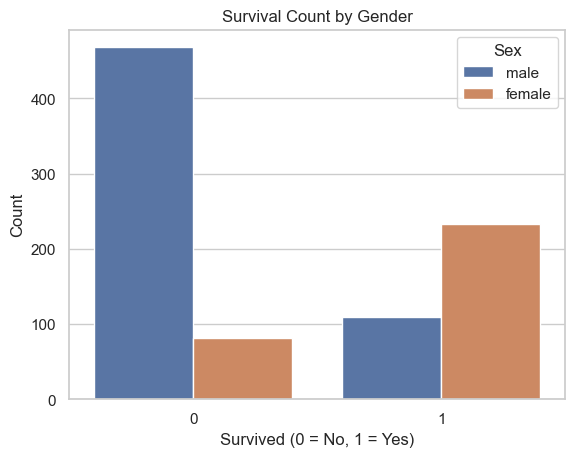

In [13]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival Count by Gender")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

*Observation:*  
The count plot shows that a significantly higher proportion of females survived compared to males.  
Most male passengers did not survive, indicating that gender played a major role in survival outcome.

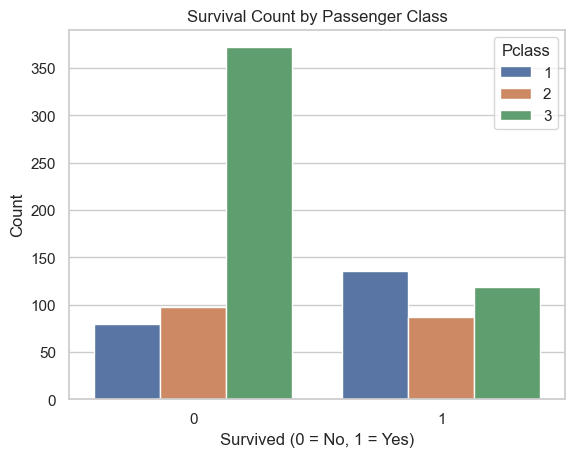

In [14]:
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title("Survival Count by Passenger Class")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

*Observation:*  
Passengers in *1st class* had the highest survival rate, while those in *3rd class* had the lowest.  
This indicates that *passenger class was strongly associated* with survival chances.

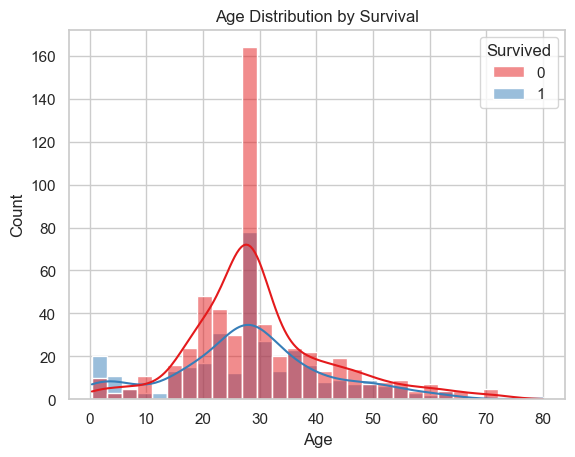

In [15]:
sns.histplot(data=df, x='Age', hue='Survived', kde=True, palette='Set1')
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

*Observation:*  
Most passengers were between *20–40 years old*.  
Survivors appear to be more common in the *younger age groups*, but survival occurred across all ages.

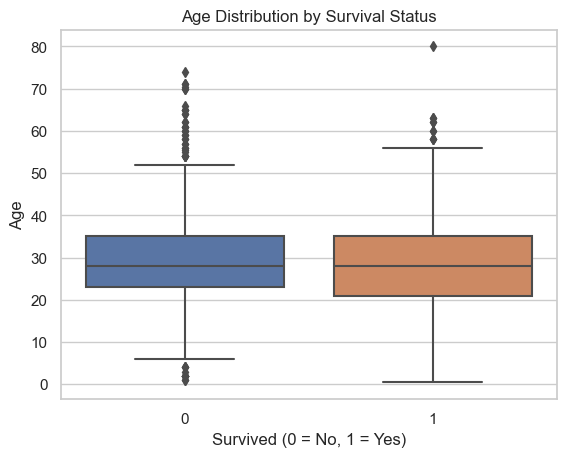

In [16]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

*Observation:*  
The *median age* of survivors appears to be slightly lower than that of non-survivors.  
There are some *outliers* in both groups, but age alone does not guarantee survival.

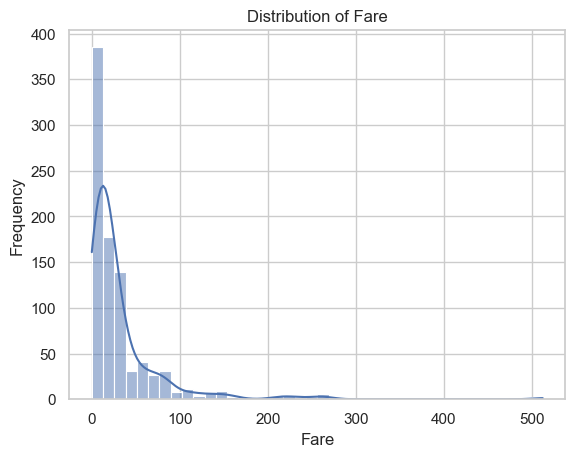

In [17]:
sns.histplot(df['Fare'], bins=40, kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

Observation:  
The fare distribution is highly right-skewed, with most passengers paying a lower fare. A few passengers paid significantly higher fares, indicating potential outliers or different ticket classes.

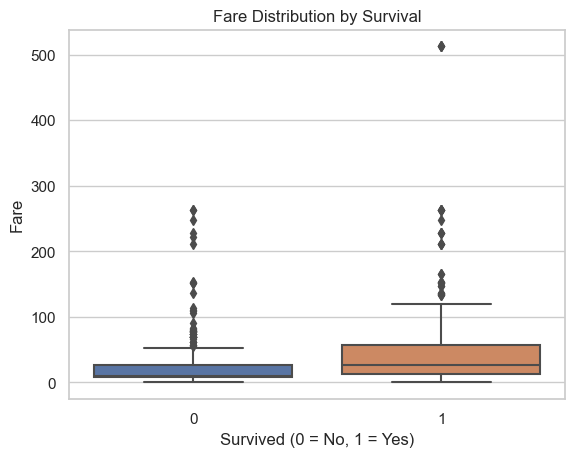

In [18]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

Observation:  
Passengers who *survived* generally paid *higher fares* on average compared to those who didn’t. This could indicate that passengers in higher classes had better chances of survival.

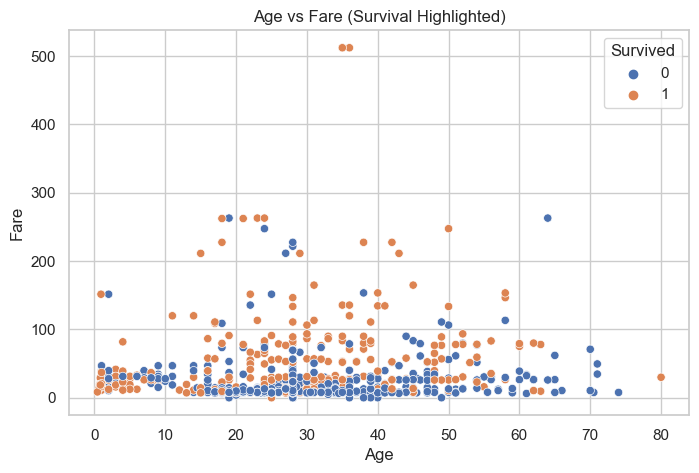

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title("Age vs Fare (Survival Highlighted)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title='Survived')
plt.show()

*Observation:*  
There is a dense cluster of passengers who paid lower fares and were between 20–40 years old.  
Survivors appear more frequently in *higher fare and younger age groups*, reinforcing earlier insights.

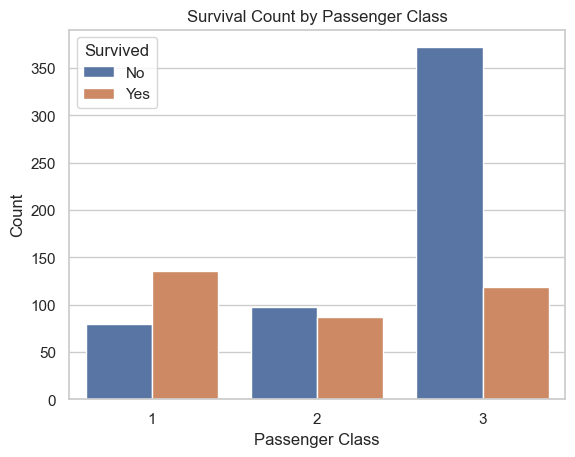

In [20]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

Observation:  
Passengers in 1st class had the highest survival rate, followed by those in 2nd class, while 3rd class passengers had the lowest. This indicates a strong correlation between socio-economic status and chances of survival.

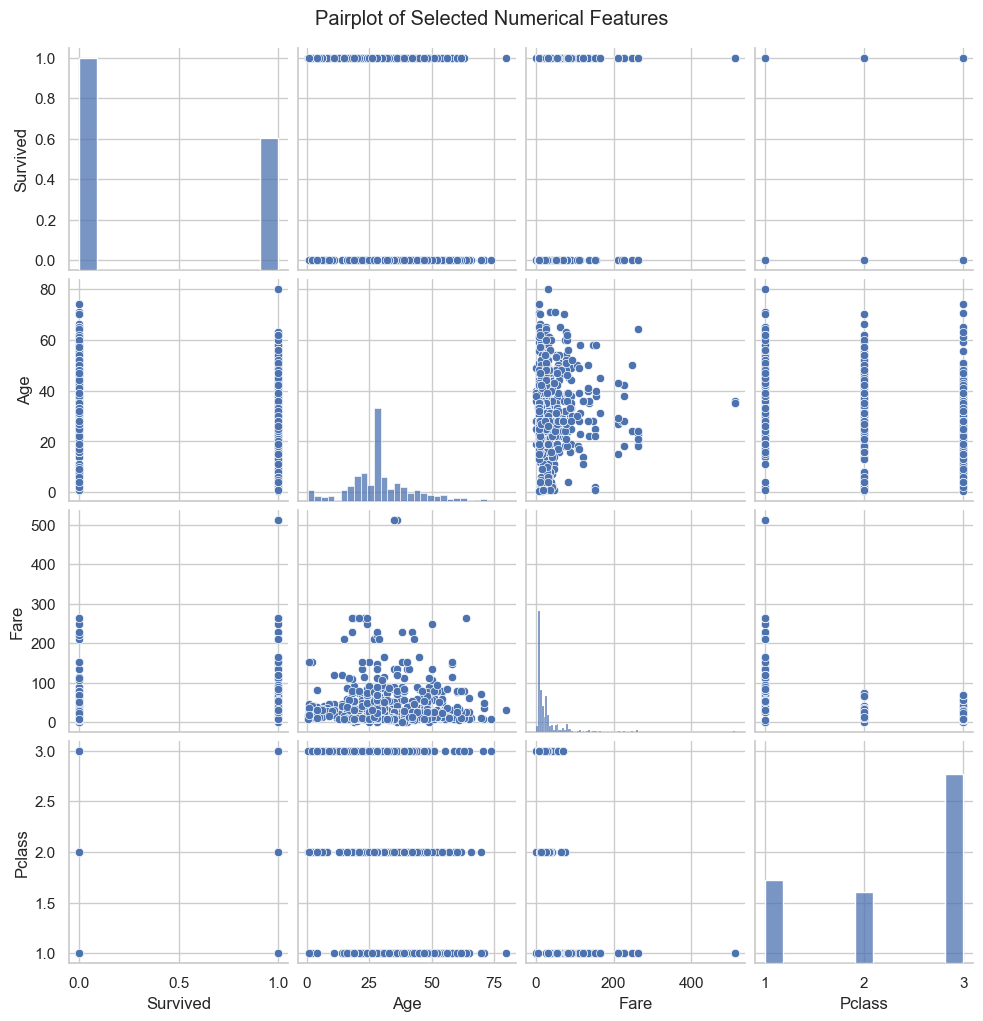

In [21]:
sns.pairplot(df[['Survived', 'Age', 'Fare', 'Pclass']])
plt.suptitle("Pairplot of Selected Numerical Features", y=1.02)
plt.show()

*Observation:*  
There is a dense cluster of passengers who paid lower fares and were between 20–40 years old.  
Survivors appear more frequently in *higher fare and younger age groups*, reinforcing earlier insights.

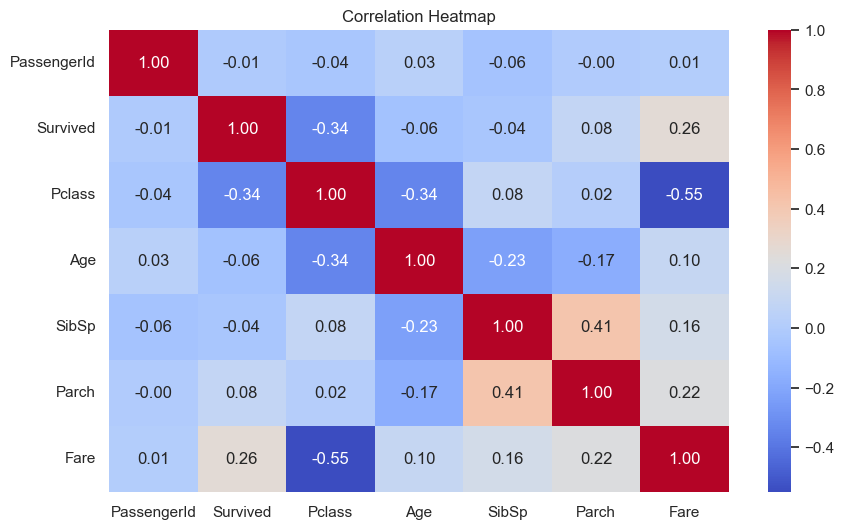

In [22]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

Observation:  
The heatmap shows a positive correlation between Fare and Survived, and a negative correlation between Pclass and Survived.  
This confirms that higher class and fare are associated with a better chance of survival.

## Summary of Findings:

- *Gender:* Female passengers had a significantly higher survival rate than males.
- *Passenger Class:* 1st class passengers had better survival chances than those in 2nd and 3rd class.
- *Fare:* Passengers who paid higher fares were more likely to survive.
- *Age:* Most passengers were between 20–40 years old. Survival was slightly higher among younger passengers.
- *Embarked Port:* Most passengers boarded from port 'S', and survival rates varied slightly by embarkation point.
- *Correlations:* Fare and Pclass showed the strongest correlations with survival. Higher fare and lower class number (1st class) indicated a better chance of survival.

This analysis highlights how socio-economic status, gender, and ticket fare played important roles in survival outcomes aboard the Titanic.